In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from pathlib import Path

In [17]:
#import data

BASE_DIR = Path.cwd().parent.parent
def load_data(path):
    full_path = BASE_DIR / path
    print(full_path)
    df = pd.read_csv(full_path, index_col=0, parse_dates=True)
    return df



def encode_features(train_df, test_df, resolution="daily"):
    # TRAIN
    train_final = train_df[["energy_demand"]].copy()
    train_final = train_final.reset_index().rename(columns={
        "utc_timestamp": "ds",
        "energy_demand": "y"
    })
    train_final["ds"] = train_final["ds"].dt.tz_localize(None)
    train_final = train_final.sort_values("ds")

    # TEST
    test_final = test_df[["energy_demand"]].copy()
    test_final = test_final.reset_index().rename(columns={
        "utc_timestamp": "ds",
        "energy_demand": "y"
    })
    test_final["ds"] = test_final["ds"].dt.tz_localize(None)
    test_final = test_final.sort_values("ds")

    return train_final, test_final

In [18]:
train_path_daily= "data/processed/residential4_energy_demand_daily_train.csv"
test_path_daily= "data/processed/residential4_energy_demand_daily_test.csv"
train_path_hourly= "data/processed/residential4_energy_demand_hourly_train.csv"
test_path_hourly= "data/processed/residential4_energy_demand_hourly_test.csv"

train_df_d = load_data(train_path_daily)
test_df_d  = load_data(test_path_daily)

train_df_h = load_data(train_path_hourly)
test_df_h  = load_data(test_path_hourly)

train_df_d, test_df_d = encode_features(train_df_d, test_df_d, resolution="daily")
train_df_h, test_df_h = encode_features(train_df_h, test_df_h, resolution="hourly")


train_df_d["ds"] = pd.to_datetime(train_df_d["ds"])
test_df_d["ds"]  = pd.to_datetime(test_df_d["ds"])

train_df_d = train_df_d.set_index("ds").sort_index()
test_df_d  = test_df_d.set_index("ds").sort_index()

y_daily = train_df_d["y"].asfreq("D")


train_df_h["ds"] = pd.to_datetime(train_df_h["ds"])
test_df_h["ds"]  = pd.to_datetime(test_df_h["ds"])

train_df_h = train_df_h.set_index("ds").sort_index()
test_df_h  = test_df_h.set_index("ds").sort_index()

y_hourly = train_df_h["y"].asfreq("h")

/home/rom1/PycharmProjects/ML_for_Data_Analytics_Project/data/processed/residential4_energy_demand_daily_train.csv
/home/rom1/PycharmProjects/ML_for_Data_Analytics_Project/data/processed/residential4_energy_demand_daily_test.csv
/home/rom1/PycharmProjects/ML_for_Data_Analytics_Project/data/processed/residential4_energy_demand_hourly_train.csv
/home/rom1/PycharmProjects/ML_for_Data_Analytics_Project/data/processed/residential4_energy_demand_hourly_test.csv


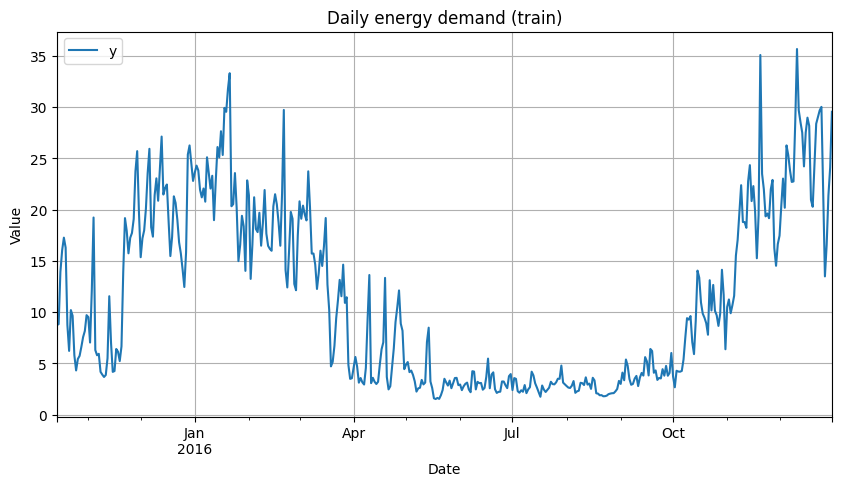

In [20]:
train_df_d.plot(figsize=(10,5))
plt.title("Daily energy demand (train)")
plt.xlabel("Date")
plt.ylabel("Value")
plt.grid()
plt.show()

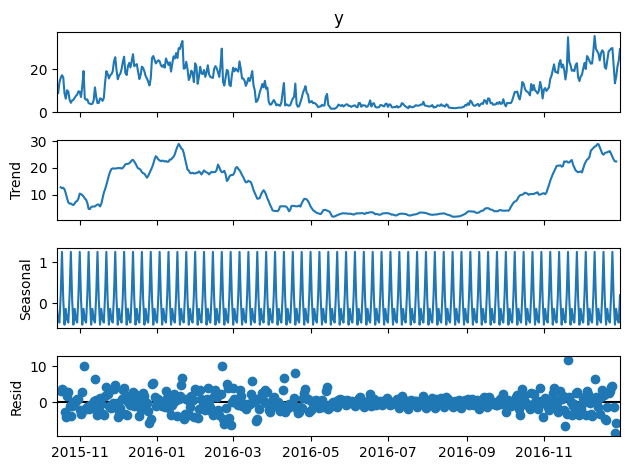

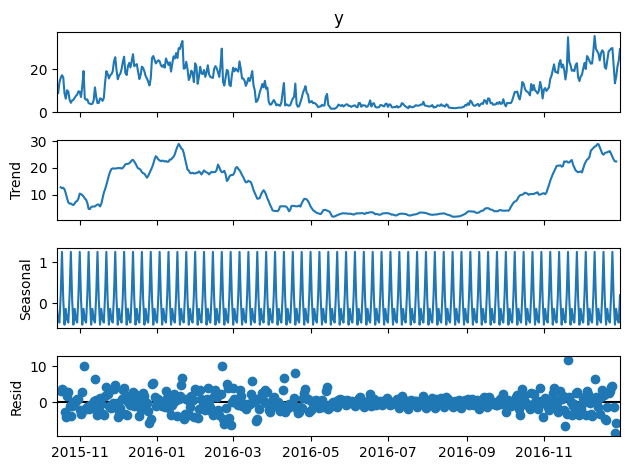

In [22]:
result = seasonal_decompose(train_df_d.iloc[:,0], model='additive', period=7)
result.plot()

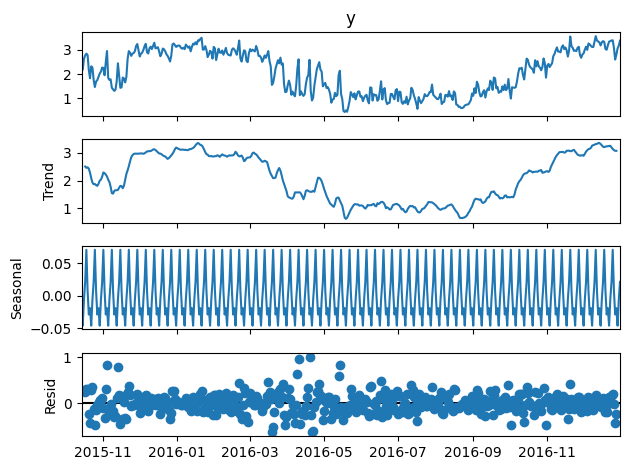

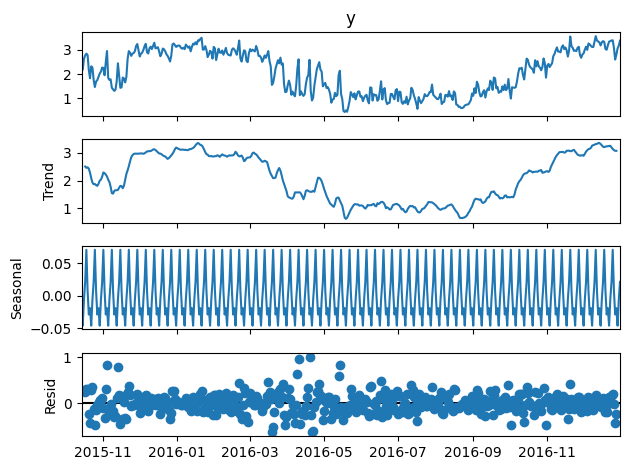

In [25]:
result = seasonal_decompose(np.log(train_df_d.iloc[:,0]), model='additive', period=7)
result.plot()